## Introduction
Retail businesses generate large amounts of transactional data that help organizations understand customer behavior, product performance, and profitability trends. Data visualization allows analysts to transform raw data into meaningful insights that support decision-making.

This project analyzes retail sales data using multiple visualizations to identify patterns in sales, profit, discounts, and regional performance.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# make plots look clean
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# Load data
df = pd.read_excel("SampleSuperstoreSubset.xls")

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7981,CA-2011-103800,2013-01-03,2013-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,740,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,741,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,742,CA-2011-112326,2013-01-04,2013-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,1760,CA-2011-141817,2013-01-05,2013-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
# Convert dates to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# VISUALIZATION 1 — Sales by Category

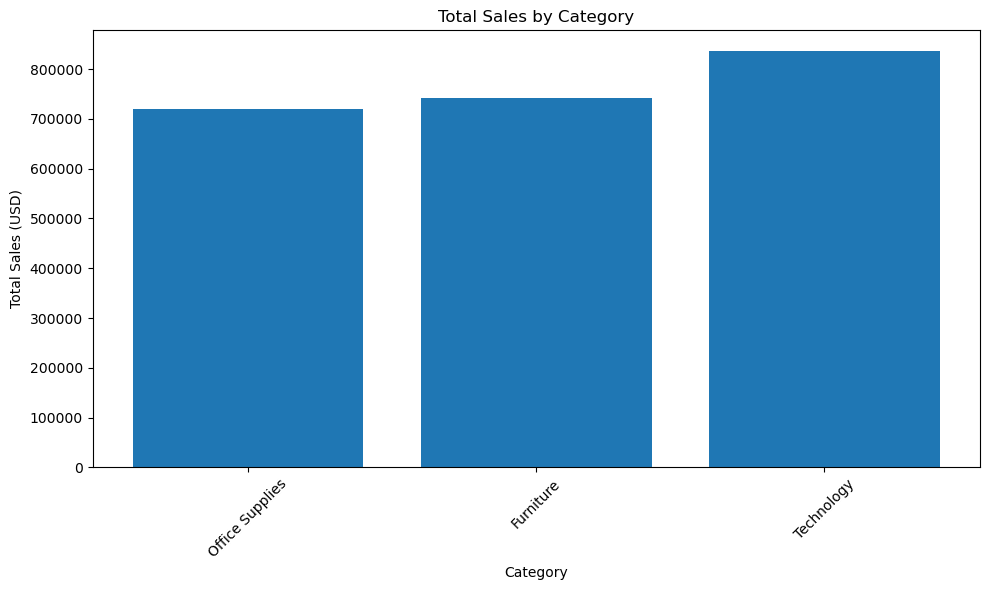

In [ ]:
# Aggregate data
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values()

fig, ax = plt.subplots()

# Plotting using axes object
ax.bar(
    sales_by_category.index,
    sales_by_category.values
)

# Labels and title
ax.set_title("Total Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales (USD)")
ax.tick_params(axis='x', rotation=45)

# Layout
fig.tight_layout()

plt.show()

## Analysis
The bar chart shows total sales across product categories. Technology and Furniture  generate strong revenue compared to Office Supplies, indicating higher customer demand and purchasing frequency in these categories.

This suggests that customers prioritize functional and frequently used products, especially technology-related items that support modern digital lifestyles.


# VISUALIZATION 2 — Profit by Sub-Category

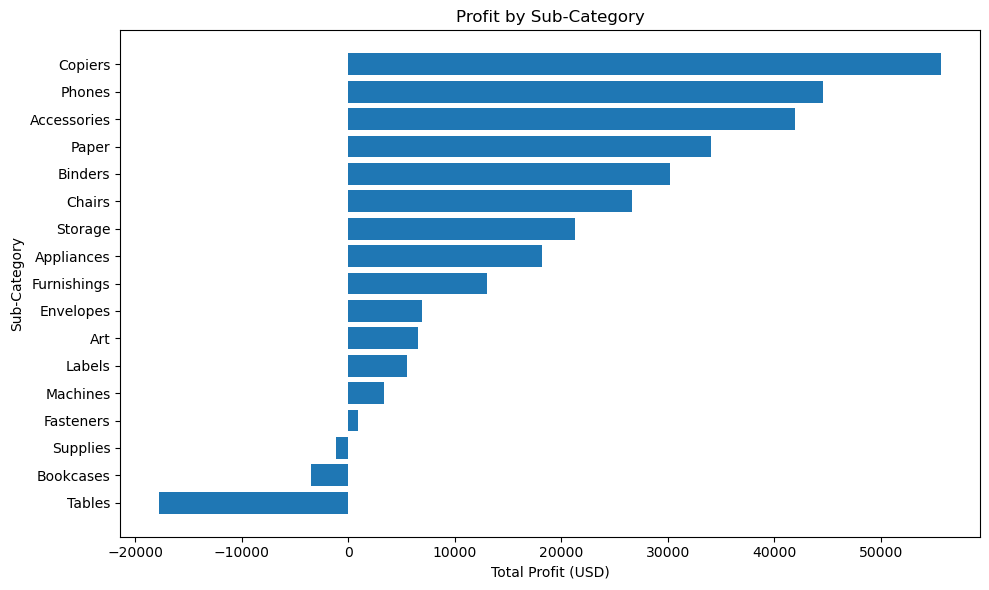

In [ ]:
# Aggregate data
profit_by_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

fig, ax = plt.subplots()

# Horizontal bar chart
ax.barh(
    profit_by_subcat.index,
    profit_by_subcat.values
)

# Titles and labels
ax.set_title("Profit by Sub-Category")
ax.set_xlabel("Total Profit (USD)")
ax.set_ylabel("Sub-Category")

# Layout adjustment
fig.tight_layout()

plt.show()

## Analysis
The profit distribution across sub-categories reveals that not all high-selling products are equally profitable. Some categories contribute significantly to profit, while others generate lower returns despite sales volume.

This indicates that businesses must evaluate profitability alongside revenue when making strategic decisions.

# VISUALIZATION 3 — Monthly Sales Trend

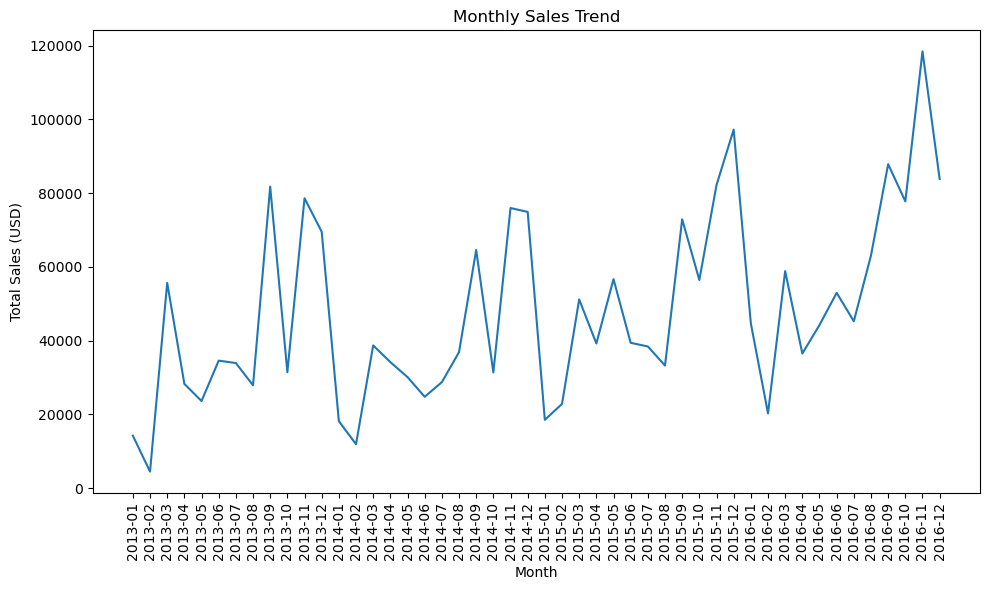

In [ ]:
# Creating Year-Month column
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Aggregate monthly sales
monthly_sales = df.groupby("YearMonth")["Sales"].sum()


fig, ax = plt.subplots()

# Line plot
ax.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

# Titles and labels
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales (USD)")
ax.tick_params(axis='x', rotation=90)

# Adjust layout
fig.tight_layout()

plt.show()

## Analysis
The monthly sales trend highlights fluctuations in purchasing behavior over time. Peaks in sales may reflect seasonal demand, promotions, or consumer purchasing cycles.

# VISUALIZATION 4 — Discount vs Profit (Scatter Plot)

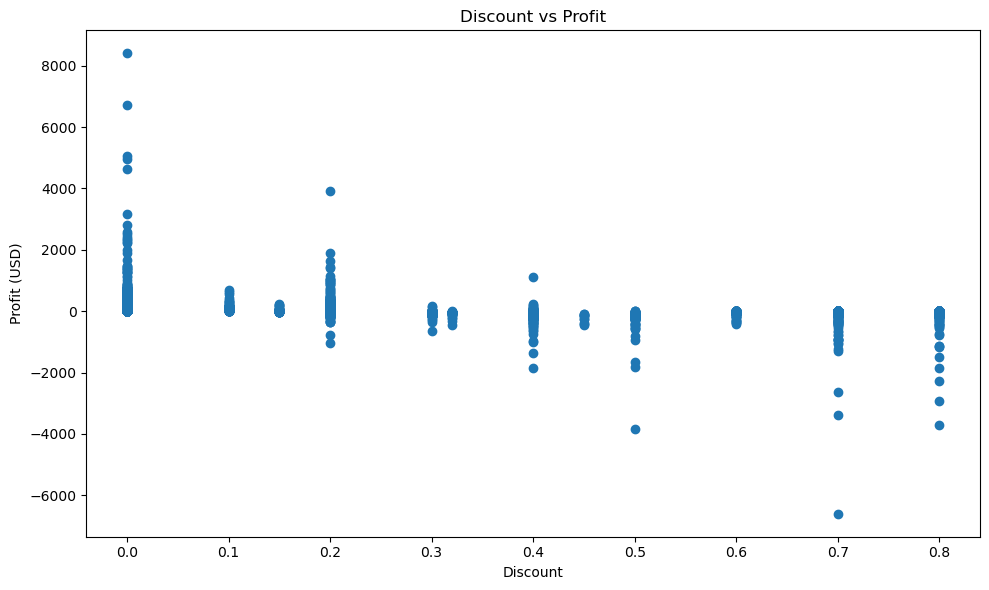

In [ ]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(df["Discount"], df["Profit"])

# Titles and labels
ax.set_title("Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit (USD)")

# Layout adjustment
fig.tight_layout()

plt.show()

## Analysis
The scatter plot shows the relationship between discounts and profit. Higher discounts often correspond with reduced profitability, suggesting that aggressive discount strategies may negatively impact business performance.

# VISUALIZATION 5 — Regional Sales Comparison

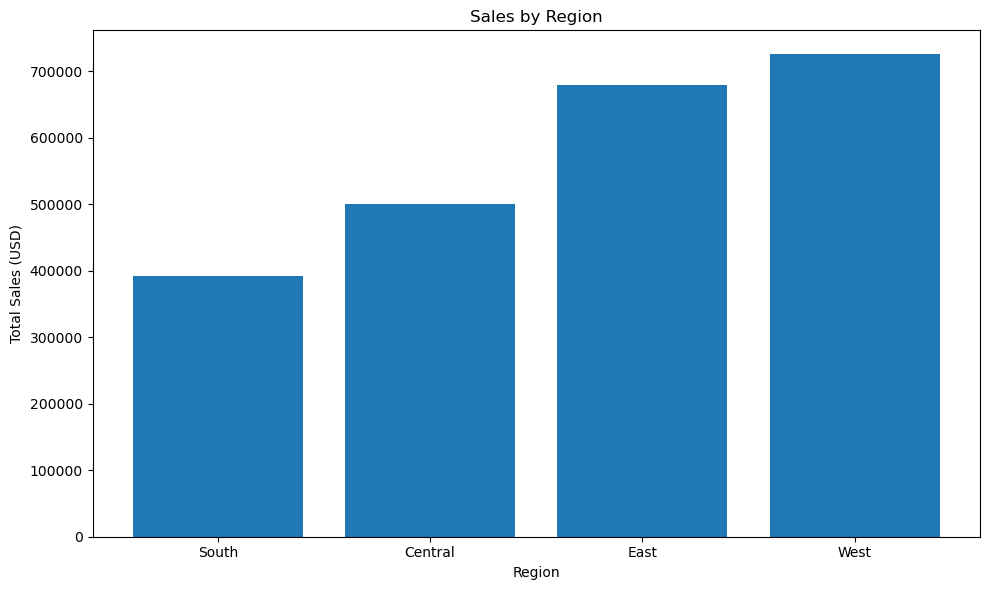

In [ ]:
# Aggregate data
regional_sales = df.groupby("Region")["Sales"].sum().sort_values()


fig, ax = plt.subplots()

# Bar chart
ax.bar(
    regional_sales.index,
    regional_sales.values
)

# Titles and labels
ax.set_title("Sales by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total Sales (USD)")

# Adjust layout
fig.tight_layout()

plt.show()

## Analysis
Regional sales comparisons reveal differences in market performance across geographic areas. Some regions contribute significantly more revenue, indicating stronger customer bases or higher demand.

These insights help companies prioritize marketing and expansion strategies.

# VISUALIZATION 6- Sales vs Profit Scatter

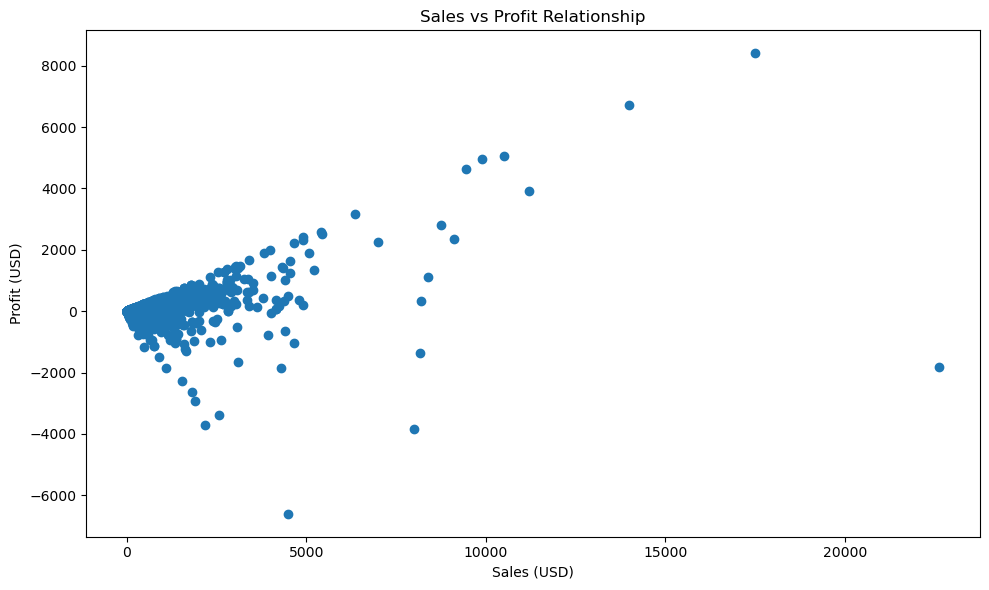

In [ ]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(df["Sales"], df["Profit"])

# Titles and labels
ax.set_title("Sales vs Profit Relationship")
ax.set_xlabel("Sales (USD)")
ax.set_ylabel("Profit (USD)")

# Layout adjustment
fig.tight_layout()

plt.show()

## Analysis
The relationship between sales and profit shows that higher sales do not always guarantee higher profitability. Some transactions generate strong revenue but limited profit due to costs or discounts.

# Conclusions

- Sales performance varies across categories, regions, and time periods, demonstrating the importance of data-driven decision-making.
- Discounts can increase sales volume but often reduce overall profitability.

## Future Outlook
As retail continues to evolve, combining data analytics with immersive technologies like augmented reality will enable smarter business strategies and more interactive customer experiences. 

# Future Technology Perspective

Retail analytics helps businesses understand customer behavior and operational performance. As digital commerce evolves, future technologies such as augmented reality, artificial intelligence, and interactive analytics platforms may enhance how customers explore and purchase products.

For example, immersive shopping tools could allow customers to visualize products before purchase, improving decision-making and reducing returns. While this dataset focuses on historical sales performance, the insights gained from data visualization can guide how companies adopt emerging technologies to improve customer experience and business outcomes.